In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# ==========================================
torch.manual_seed(42)

R = 8.314        
Tm0 = 653.15      # K 380
T_inf = 377.15    # Vogel K 134-30

# ==========================================
# 1
# ==========================================
try:
    df = pd.read_csv('nonisoDatepeekcf2.csv')
except FileNotFoundError:
    T_all, X_all, dXdt_all, Phi_all = [], [], [], []
    for rate in [5, 10, 20, 30, 40]:  
        t = np.linspace(0.1, 100, 200)
        T = 600.0 - (rate / 60.0) * t 
        X = 1.0 - np.exp(-(0.05 * t)**(2.5)) 
        dXdt = np.gradient(X, t)
        T_all.extend(T); X_all.extend(X); dXdt_all.extend(dXdt); Phi_all.extend([rate]*200)
    df = pd.DataFrame({'Temp_K': T_all, 'X': X_all, 'dXdt': dXdt_all, 'Phi': Phi_all})

T_exp = torch.tensor(df['Temp_K'].values, dtype=torch.float32).view(-1, 1)
X_exp = torch.tensor(df['X'].values, dtype=torch.float32).view(-1, 1)
dXdt_true = torch.tensor(df['dXdt'].values, dtype=torch.float32).view(-1, 1)
Phi_exp = torch.tensor(df['Phi'].values, dtype=torch.float32).view(-1, 1)

valid_mask = (X_exp > 0.0001) & (X_exp < 0.9999) & (dXdt_true > 0)
T_exp = T_exp[valid_mask].view(-1, 1)
X_exp = X_exp[valid_mask].view(-1, 1)
dXdt_true = dXdt_true[valid_mask].view(-1, 1)
Phi_exp = Phi_exp[valid_mask].view(-1, 1)

In [2]:
# ==========================================
# 2
# ==========================================
class DecoupledDoubleBlackBoxModel(nn.Module):
    def __init__(self):
        super(DecoupledDoubleBlackBoxModel, self).__init__()
        
        # ---------------------------------------------
        # ---------------------------------------------
        self.net_mn = nn.Sequential(
            nn.Linear(2, 6),
            nn.Tanh(),  
            nn.Linear(6, 6),
            nn.Tanh(),
            nn.Linear(6, 2)
        )
        
        # ---------------------------------------------
        # ---------------------------------------------
        self.net_thermo = nn.Sequential(
            nn.Linear(1, 4),
            nn.Tanh(),
            nn.Linear(4, 4),
            nn.Tanh(),
            nn.Linear(4, 2)
        )
        
        # 
        self.log_K0 = nn.Parameter(torch.tensor([11.0])) 

    def forward(self, T, X, Phi):
        Phi_scaled = Phi / 50.0  
        
        # ==================================
        inputs_mn = torch.cat([X, Phi_scaled], dim=1)
        out_mn = self.net_mn(inputs_mn)
        
        m_dynamic = F.softplus(out_mn[:, 0:1]) + 0.1
        n_dynamic = F.softplus(out_mn[:, 1:2]) + 0.1
        
        # ==================================
        out_thermo = self.net_thermo(Phi_scaled)
        
        #
        U_star_scaled = 1.0 + F.softplus(out_thermo[:, 0:1]) 
        Kg_scaled = 2.0 + F.softplus(out_thermo[:, 1:2])     
        
        U_star = U_star_scaled * 1000.0   
        Kg = Kg_scaled * 100000.0         
        K0 = torch.exp(self.log_K0)*1000000
        
        # ==================================
        delta_T = Tm0 - T
        f = 2 * T / (Tm0 + T)
        
        safe_T_diff = torch.clamp(T - T_inf, min=1.0)
        safe_denom = torch.clamp(T * delta_T * f, min=1.0)
        
        term_diffusion = torch.exp(-U_star / (R * safe_T_diff))
        term_nucleation = torch.exp(-Kg / safe_denom)
        
        K_T = K0 * term_diffusion * term_nucleation
        
        #dX/dt
        X_safe = torch.clamp(X, 1e-4, 1.0 - 1e-4)
        term_autocatalytic = torch.pow(X_safe, m_dynamic)
        term_impingement = torch.pow(1.0 - X_safe, n_dynamic)
        
        dXdt_pred = K_T * term_autocatalytic * term_impingement
        
        return dXdt_pred, m_dynamic, n_dynamic, U_star, Kg

model = DecoupledDoubleBlackBoxModel()

In [3]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ==========================================
# ==========================================
EPOCHS = 40000
loss_history = []

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    
    dXdt_pred, _, _, _, _ = model(T_exp, X_exp, Phi_exp)
    loss = torch.mean((dXdt_pred - dXdt_true) ** 2)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    loss_history.append(loss.item())

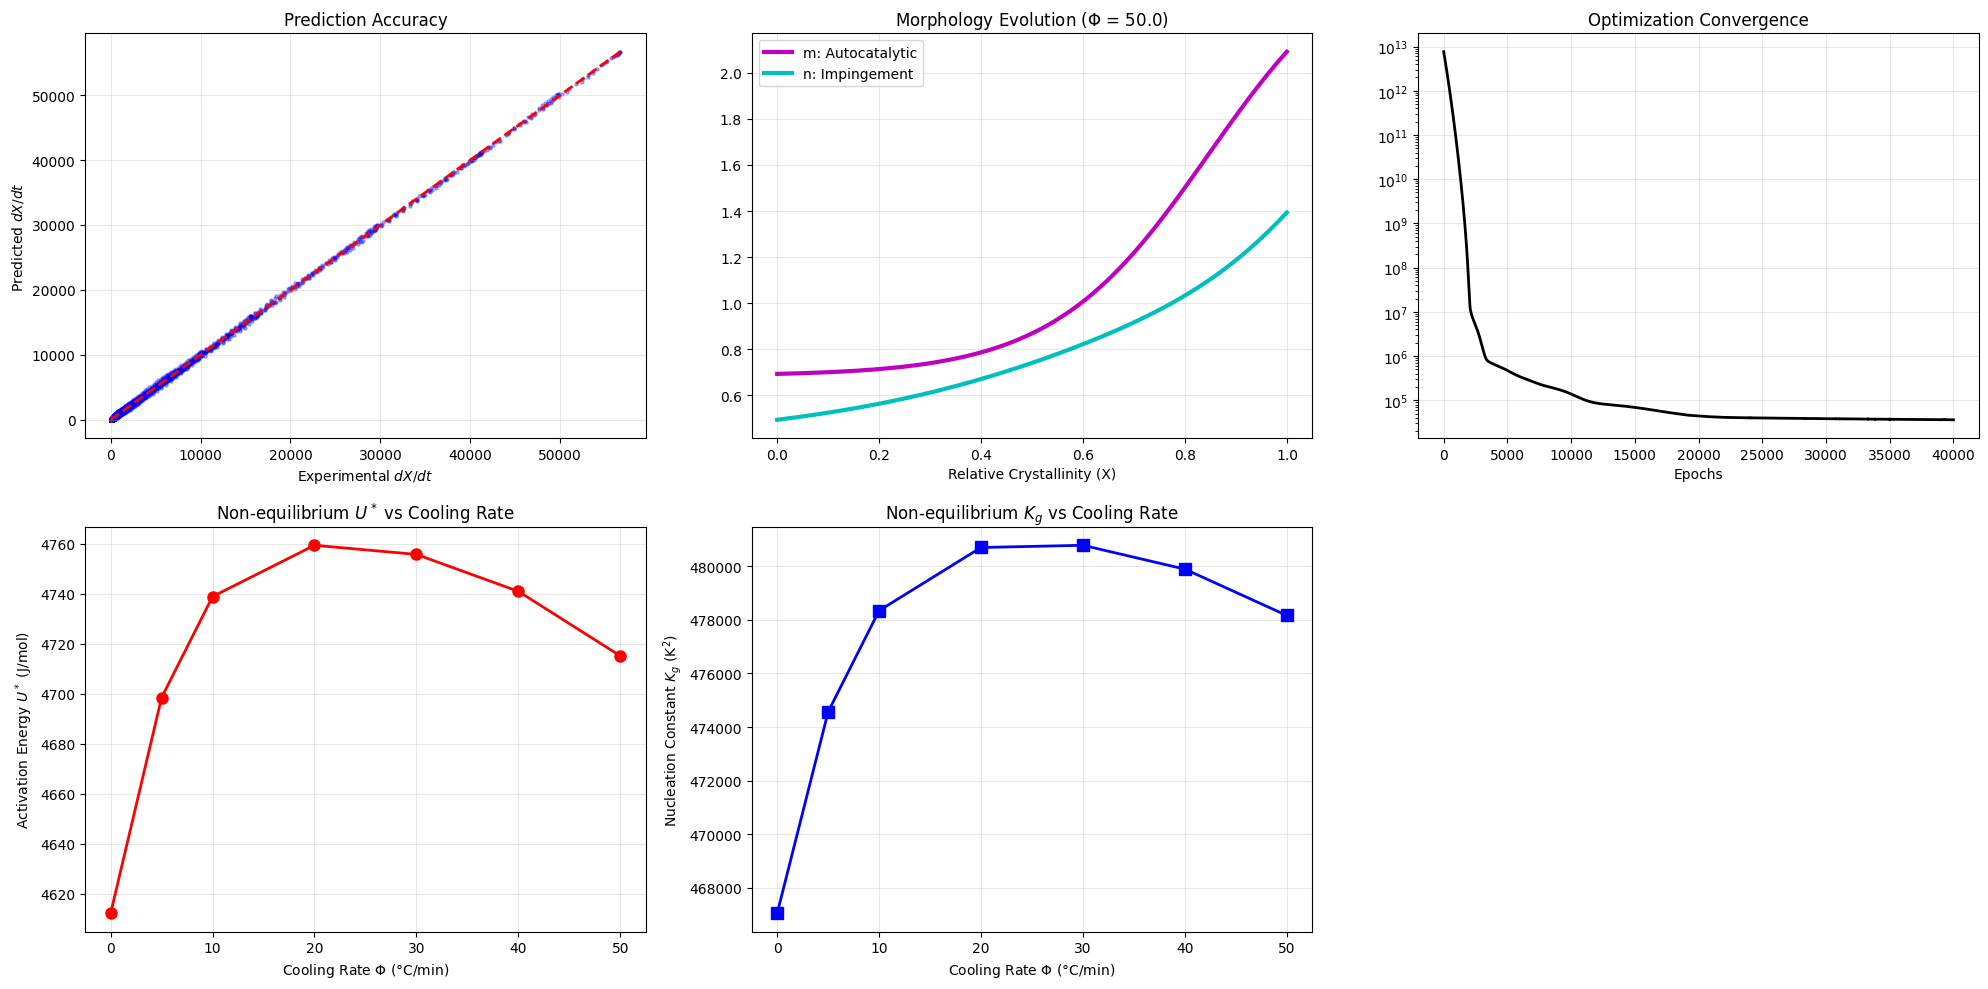

In [4]:
# ==========================================
# ==========================================
model.eval()
with torch.no_grad():
    dXdt_final_pred, m_final, n_final, U_star_final, Kg_final = model(T_exp, X_exp, Phi_exp)
    
    unique_phis = torch.unique(Phi_exp).view(-1, 1)
    out_thermo_unique = model.net_thermo(unique_phis / 50.0)
    U_star_unique = (1.0 + F.softplus(out_thermo_unique[:, 0])) * 1000.0
    Kg_unique = (2.0 + F.softplus(out_thermo_unique[:, 1])) * 100000.0

plt.figure(figsize=(20, 10))

# [1]
plt.subplot(2, 3, 1)
plt.scatter(dXdt_true.numpy(), dXdt_final_pred.numpy(), alpha=0.3, c='b', s=5)
max_v = max(dXdt_true.max().item(), dXdt_final_pred.max().item())
plt.plot([0, max_v], [0, max_v], 'r--', lw=2)
plt.xlabel('Experimental $dX/dt$')
plt.ylabel('Predicted $dX/dt$')
plt.title('Prediction Accuracy')
plt.grid(True, alpha=0.3)

# [2]
plt.subplot(2, 3, 2)
sample_phi = float(Phi_exp[len(Phi_exp)//2].item()) 
mask = (Phi_exp.squeeze() == sample_phi)
if mask.sum() > 0:
    X_plot = X_exp[mask].squeeze().numpy()
    m_plot = m_final[mask].squeeze().numpy()
    n_plot = n_final[mask].squeeze().numpy()
    sort_idx = np.argsort(X_plot)
    plt.plot(X_plot[sort_idx], m_plot[sort_idx], 'm-', lw=3, label='m: Autocatalytic')
    plt.plot(X_plot[sort_idx], n_plot[sort_idx], 'c-', lw=3, label='n: Impingement')
    plt.title(f'Morphology Evolution ($\Phi$ = {sample_phi:.1f})')
    plt.legend()
plt.xlabel('Relative Crystallinity (X)')
plt.grid(True, alpha=0.3)

# [3]
plt.subplot(2, 3, 4)
plt.plot(unique_phis.numpy(), U_star_unique.detach().numpy(), 'ro-', lw=2, markersize=8)
plt.xlabel('Cooling Rate $\Phi$ (°C/min)')
plt.ylabel('Activation Energy $U^*$ (J/mol)')
plt.title('Non-equilibrium $U^*$ vs Cooling Rate')
plt.grid(True, alpha=0.3)

# [4]
plt.subplot(2, 3, 5)
plt.plot(unique_phis.numpy(), Kg_unique.detach().numpy(), 'bs-', lw=2, markersize=8)
plt.xlabel('Cooling Rate $\Phi$ (°C/min)')
plt.ylabel('Nucleation Constant $K_g$ (K$^2$)')
plt.title('Non-equilibrium $K_g$ vs Cooling Rate')
plt.grid(True, alpha=0.3)

# [5]
plt.subplot(2, 3, 3)
plt.plot(loss_history, 'k-', lw=2)
plt.yscale('log')
plt.xlabel('Epochs')
plt.title('Optimization Convergence')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np
import os

# Excel
excel_filename = "30PEEKcf_Figures_Data_All0604.xlsx"

print(f"\nOrganizing plotting data and exporting to Excel: {excel_filename} ...")

#
phi_all_np = Phi_exp.squeeze().detach().numpy()
x_all_np = X_exp.squeeze().detach().numpy()
m_all_np = m_final.squeeze().detach().numpy()
n_all_np = n_final.squeeze().detach().numpy()
dxdt_true_np = dXdt_true.squeeze().detach().numpy()
dxdt_pred_np = dXdt_final_pred.squeeze().detach().numpy()

# ---------------------------------------------------------
# 1
# ---------------------------------------------------------
df_fig1 = pd.DataFrame({
    'Exp_dXdt_True': dxdt_true_np,
    'Pred_dXdt_Model': dxdt_pred_np
})

# ---------------------------------------------------------
# 2
# ---------------------------------------------------------
unique_rates = np.unique(phi_all_np)
df_fig2_list = []

for rate in unique_rates:
    #
    mask = (phi_all_np == rate)
    x_rate = x_all_np[mask]
    m_rate = m_all_np[mask]
    n_rate = n_all_np[mask]
    
    #
    sort_idx = np.argsort(x_rate)
    
    #
    df_temp = pd.DataFrame({
        f'X_Phi_{rate:g}': x_rate[sort_idx],
        f'm_Phi_{rate:g}': m_rate[sort_idx],
        f'n_Phi_{rate:g}': n_rate[sort_idx]
    })
    df_fig2_list.append(df_temp)

#
df_fig2_all = pd.concat(df_fig2_list, axis=1)

# ---------------------------------------------------------
# 3
# ---------------------------------------------------------
df_thermo = pd.DataFrame({
    'Cooling_Rate_Phi': unique_phis.squeeze().numpy(),
    'U_star_J_mol': U_star_unique.detach().squeeze().numpy(),
    'Kg_K2': Kg_unique.detach().squeeze().numpy()
})
#
df_thermo = df_thermo.sort_values(by='Cooling_Rate_Phi').reset_index(drop=True)

# ---------------------------------------------------------
# 4
# ---------------------------------------------------------
df_loss = pd.DataFrame({
    'Epoch': np.arange(1, len(loss_history) + 1),
    'MSE_Loss': loss_history
})

# ---------------------------------------------------------
# 5
# ---------------------------------------------------------
try:
    with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
        df_fig1.to_excel(writer, sheet_name='Fig1_Parity_Plot', index=False)
        df_fig2_all.to_excel(writer, sheet_name='Fig2_All_Morphology(m,n)', index=False)
        df_thermo.to_excel(writer, sheet_name='Fig3_4_Thermo_Params', index=False)
        df_loss.to_excel(writer, sheet_name='Fig5_Loss_Curve', index=False)
    
    print("Full data export completed successfully!")
    
except Exception as e:
    print("!pip install openpyxl")


Organizing plotting data and exporting to Excel: 30PEEKcf_Figures_Data_All0604.xlsx ...
Full data export completed successfully!
